In [70]:
from os import rename

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
import importlib
import config
importlib.reload(config)

from config import US_TICKERS_FILE_02,US_TICKERS_FINAL



In [50]:
df = pd.read_csv(US_TICKERS_FILE_02)
#Refactor mkt_cap and turnover
df['mkt_cap'] = df['mkt_cap']/1000000000
df['ave_daily_turnover'] = df['ave_daily_turnover']/1000000
df.rename(columns={'ave_daily_turnover':'turnover'}, inplace=True)

In [51]:
print(f'Number of separate securities: {len(df)}')
print(f'Max mkt cap: {df.mkt_cap.max()}bln')
print(f'Min mkt cap: {df.mkt_cap.min()}bln')
print(f'Max turnover: {df.turnover.max()}m')
print(f'Min turnover: {df.turnover.min()}m')

Number of separate securities: 1911
Max mkt cap: 876.296bln
Min mkt cap: 0.001512bln
Max turnover: 10549.41m
Min turnover: 8.02238e-05m


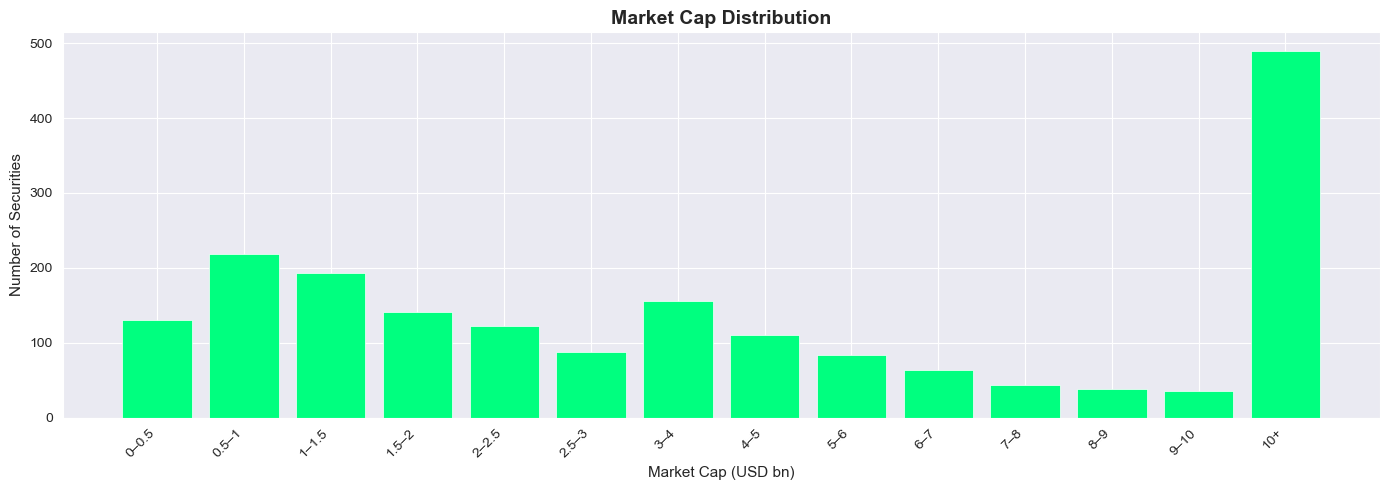

In [58]:

# Define bin edges:
bins = [0, 0.5, 1, 1.5, 2, 2.5, 3, 4, 5, 6, 7, 8, 9, 10, df['mkt_cap'].max()]

labels = ['0–0.5','0.5–1','1–1.5','1.5–2','2–2.5','2.5–3','3–4','4–5','5–6','6–7','7–8','8–9','9–10','10+']

df['mkt_cap_bin'] = pd.cut(df['mkt_cap'], bins=bins, labels=labels, right=False)

fig, ax = plt.subplots(figsize=(14, 5))
counts = df['mkt_cap_bin'].value_counts().reindex(labels)
ax.bar(labels, counts, color='springgreen', edgecolor='white', linewidth=0.5)

ax.set_title('Market Cap Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Market Cap (USD bn)', fontsize=11)
ax.set_ylabel('Number of Securities', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [59]:
mkt_cap_min = 1
turnover_min = 5

print(f'Number of separate securities: {len(df)}.')
print(f'Number of securities by mkt cap filter only  {df[df['mkt_cap']>=mkt_cap_min].shape[0]}.')
print(f'Number of securities by turnover filter only: {df[df['turnover']>=turnover_min].shape[0]}.')
print(f'Number of securities by both filters: {df[(df['turnover']>=turnover_min)&(df['mkt_cap']>=mkt_cap_min)].shape[0]}.')

Number of separate securities: 1911.
Number of securities by mkt cap filter only  1562.
Number of securities by turnover filter only: 1609.
Number of securities by both filters: 1469.


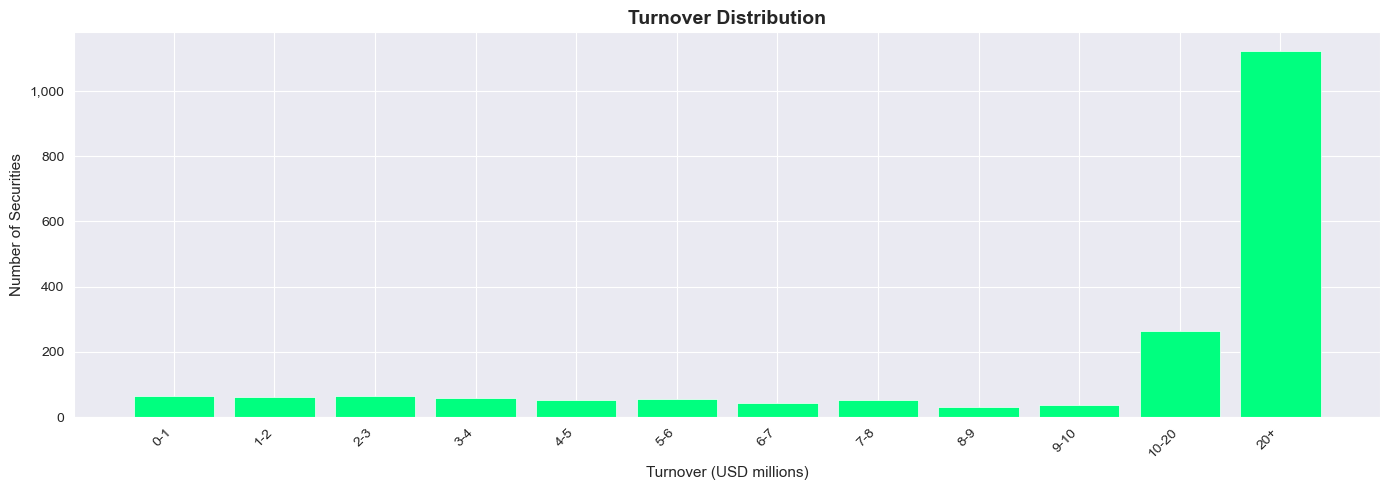

In [57]:
# Define bin edges:
bins = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10,20, df['turnover'].max()]

labels = ['0-1','1-2','2-3','3-4','4-5','5-6','6-7','7-8','8-9','9-10','10-20','20+']

df['turnover_bin'] = pd.cut(df['turnover'], bins=bins, labels=labels, right=False)

fig, ax = plt.subplots(figsize=(14, 5))
counts = df['turnover_bin'].value_counts().reindex(labels)
ax.bar(labels, counts, color='springgreen', edgecolor='white', linewidth=0.5)

ax.set_title('Turnover Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Turnover (USD millions)', fontsize=11)
ax.set_ylabel('Number of Securities', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [44]:
df[(df['turnover']>=turnover_min)&(df['mkt_cap']>=mkt_cap_min)].sort_values('turnover', ascending=True).head(10)

,ISIN,Ticker,Start_Date,End_Date,min_date,max_date,Sector,bb_tcm,alt_bb_tcm,mkt_cap,turnover,bb_tcm_note
1220,US8110544025,SSP,05/01/2018,13/06/2025,02/01/2018,28/03/2024,Consumer Discretionary,SSP US,NaN,1.254711,5.021609,NaN
835,US3020811044,EXLS,23/01/2018,24/06/2025,02/01/2018,28/03/2024,Information Technology,EXLS US,NaN,2.143838,5.050401,NaN
1094,US46269C1027,IRDM,03/01/2018,17/06/2025,02/01/2018,28/03/2024,Communication Services,IRDM US,NaN,1.151158,5.090490,NaN
273,US63001N1063,NATL,29/01/2024,30/06/2025,02/01/2024,28/03/2024,Financials,NATL US,NaN,1.613916,5.102278,NaN
1233,US7580754023,RWT,20/01/2018,12/06/2025,25/07/2018,28/03/2024,Financials,RWT US,NaN,1.146697,5.118686,NaN
1225,US5771281012,MATW,21/01/2018,13/06/2025,02/01/2018,28/03/2024,Consumer Discretionary,MATW US,NaN,1.727599,5.140240,NaN
1025,US35243J1016,FBRT,19/10/2021,20/06/2025,19/10/2021,28/03/2024,Financials,FBRT US,NaN,1.303357,5.188604,Start_Date shifted to first regular-way tradin...
1433,US30214U1025,EXPO,19/01/2018,28/05/2025,02/01/2018,28/03/2024,Industrials,EXPO US,NaN,1.898381,5.209216,NaN
1419,US7901481009,JOE,19/01/2018,29/05/2025,01/05/2020,28/03/2024,Real Estate,JOE US,NaN,1.211689,5.229310,NaN
188,US6177001095,MORN,03/01/2018,30/06/2025,02/01/2024,28/03/2024,Financials,MORN US,NaN,4.057760,5.268194,NaN


In [61]:
df_final = df[(df['turnover']>=turnover_min)&(df['mkt_cap']>=mkt_cap_min)].sort_values('turnover', ascending=True)
print(df_final.shape)

(1469, 14)


In [71]:
df_final.to_csv(US_TICKERS_FINAL, index=False)